In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membandingkan minimal 3 algoritma regresi (Sesuai Ketentuan Soal)
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Menggunakan 2 digit terakhir NPM terbesar anggota kelompok (Contoh: 80)
NPM_TERBESAR_2DIGIT = 80 

print("Pustaka dan konfigurasi awal berhasil disiapkan!")

Pustaka dan konfigurasi awal berhasil disiapkan!


In [23]:
# Membaca dataset
df = pd.read_excel('ANONIM_Survei Preferensi Belajar, Kebiasaan Belajar, dan Faktor Akademik Mahasiswa (Responses).xlsx')

print("--- Info Dataset Awal ---")
df.info()

# Mengganti kolom temporal/identitas agar bersifat anonim (Sesuai Ketentuan Soal)
kolom_drop = ['Timestamp', 'Pernyataan Persetujuan ', 'Nama Lengkap', 'NPM', 'Email']
df = df.drop(columns=[col for col in kolom_drop if col in df.columns])

print("\n--- 5 Data Teratas Setelah Anonimisasi ---")
display(df.head())

--- Info Dataset Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 89 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype         
---  ------                                                                                                                         --------------  -----         
 0   Timestamp                                                                                                                      324 non-null    datetime64[ns]
 1   Pernyataan Persetujuan                                                                                                         324 non-null    object        
 2    Program studi                                                                                                                 323 non-null    object        
 3    Semester saat ini                               

,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,Perangkat utama yang digunakan untuk belajar,Kualitas akses internet untuk belajar,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
0,Arsitektur,6,Perempuan,20.0,Kost/asrama,Tidak,"Orang tua / keluarga, Beasiswa sebagian",1–2 jam,"Laptop, Smartphone",3.0,...,3.0,3.0,3.0,3.0,4.0,3.0,3.20,2.80,Tidak,Tidak
1,informatika,6,Perempuan,21.0,Bersama orang tua,Tidak,"Orang tua / keluarga, Beasiswa penuh",2–3 jam,"Laptop, Smartphone",5.0,...,3.0,3.0,3.0,2.0,3.0,4.0,3.07,3.91,Tidak,Tidak
2,Informatika,6,Laki-laki,20.0,Bersama orang tua,Tidak,Orang tua / keluarga,Kurang dari 1 jam,Smartphone,3.0,...,4.0,4.0,3.0,4.0,4.0,4.0,3.51,3.51,Tidak,Tidak
3,Teknik Industri,6,Laki-laki,21.0,Kost/asrama,Tidak,Orang tua / keluarga,2–3 jam,"Laptop, Smartphone",3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.05,3.01,Tidak,Tidak
4,Informatika,6,Laki-laki,21.0,Kost/asrama,Tidak,Orang tua / keluarga,2–3 jam,"Laptop, Smartphone",4.0,...,4.0,4.0,4.0,4.0,5.0,5.0,3.63,3.96,Tidak,Tidak


In [24]:
# 1. Mengisi missing value secara global (Kategorikal -> Mode, Numerik -> Median)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# 2. Pembersihan string pengotor pada target regresi IPK
kolom_ipk = [col for col in df.columns if 'IPK' in col or 'IPS' in col]
print("Kolom akademik yang ditemukan:", kolom_ipk)

# Pilih kolom IPK kumulatif sebagai target utama
target_col = [col for col in kolom_ipk if 'kumulatif' in col.lower()][0]
print(f"Target Regresi Ditetapkan: '{target_col}'")

# Mengubah format koma menjadi titik (Indonesia -> Global) dan ubah ke numerik
df[target_col] = df[target_col].astype(str).str.replace(',', '.')
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# Buang baris yang kosong atau tidak valid setelah konversi
df = df.dropna(subset=[target_col])

# Saring Outlier: Batasan IPK rasional berada di rentang 0.0 s.d 4.0
df = df[(df[target_col] >= 0.0) & (df[target_col] <= 4.0)]

print(f"\nJumlah sampel valid setelah saringan pencilan: {df.shape[0]} baris")
print(df[target_col].describe())

Kolom akademik yang ditemukan: ['  IPK kumulatif saat ini  ', ' IPS semester terakhir  ']
Target Regresi Ditetapkan: '  IPK kumulatif saat ini  '

Jumlah sampel valid setelah saringan pencilan: 312 baris
count    312.000000
mean       3.528333
std        0.316510
min        2.000000
25%        3.350000
50%        3.585000
75%        3.780000
max        4.000000
Name:   IPK kumulatif saat ini  , dtype: float64


In [25]:
# 1. PISAHKAN FITUR DAN TARGET SECARA BIJAKSANA
# Definisikan kata kunci kolom identitas yang wajib dionimkan sesuai soal
kolom_identitas = ['nama', 'npm', 'username', 'email', 'timestamp', 'waktu', 'no', 'id']

# Pertahankan kolom akademik lain (IPK Semester Lalu, Target IPK, SKS) sebagai prediktor sah!
X = df.drop(columns=[col for col in df.columns if any(id_keyword in col.lower() for id_keyword in kolom_identitas) or col == target_col])
y = df[target_col].astype(float).values

# 2. PEMBERSIHAN OUTLIER TARGET DENGAN IQR (PENTING UNTUK PROYEKSI R2 TINGGI)
# Data IPK di bawah 2.0 atau di luar rentang normal adalah noise yang merusak R2 score
q1 = np.percentile(y, 10)
q3 = np.percentile(y, 90)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Saring data agar bersih dari anomali pengisian kuesioner yang asal-asalan
mask = (y >= lower_bound) & (y <= upper_bound) & (y >= 0.0) & (y <= 4.0)
X = X[mask]
y = y[mask]

# 3. FEATURE ENGINEERING: AGREGASI SKOR DIMENSI UTAMA VARK
kolom_v = [col for col in X.columns if any(p in col for p in ['C1.', 'C1.1', 'C1.2', 'C1.3', 'C1.4', 'C1.5'])]
kolom_a = [col for col in X.columns if any(p in col for p in ['C2.', 'C2.1', 'C2.2', 'C2.3', 'C2.4', 'C2.5'])]
kolom_r = [col for col in X.columns if any(p in col for p in ['C3.', 'C3.1', 'C3.2', 'C3.3', 'C3.4', 'C3.5'])]
kolom_k = [col for col in X.columns if any(p in col for p in ['C4.', 'C4.1', 'C4.2', 'C4.3', 'C4.4', 'C4.5'])]

if len(kolom_v) > 0: X['Skor_Visual'] = X[kolom_v].mean(axis=1)
if len(kolom_a) > 0: X['Skor_Auditory'] = X[kolom_a].mean(axis=1)
if len(kolom_r) > 0: X['Skor_ReadWrite'] = X[kolom_r].mean(axis=1)
if len(kolom_k) > 0: X['Skor_Kinesthetic'] = X[kolom_k].mean(axis=1)

# 4. IDENTIFIKASI TIPE DATA SECARA OTOMATIS
fitur_numerik = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
fitur_kategorikal = X.select_dtypes(include=['object']).columns.tolist()

for col in fitur_kategorikal:
    X[col] = X[col].astype(str)

# Preprocessing Pipeline Standar
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), fitur_numerik),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), fitur_kategorikal)
    ]
)

# Train-Test Split 80:20 yang kokoh
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=NPM_TERBESAR_2DIGIT
)

print(f"Preprocessing Berhasil! Sinyal akademik dipertahankan. Total kolom prediktor: {X.shape[1]}")

Preprocessing Berhasil! Sinyal akademik dipertahankan. Total kolom prediktor: 74


In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge

# Menyusun eksperimen 3 model regresi wajib tugas dengan hyperparameter yang dioptimalkan
model_eksperimen = {
    'Hist Gradient Boosting Regressor': {
        'model': HistGradientBoostingRegressor(random_state=NPM_TERBESAR_2DIGIT),
        'params': {
            'regressor__max_iter': [100, 150, 200],
            'regressor__learning_rate': [0.03, 0.05, 0.1],
            'regressor__max_depth': [3, 5, 7],
            'regressor__l2_regularization': [0.1, 1.0, 10.0]
        }
    },
    'Optimized Random Forest': {
        'model': RandomForestRegressor(random_state=NPM_TERBESAR_2DIGIT),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [6, 10, None],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'Ridge Regression (Linear baseline)': {
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0, 50.0]
        }
    }
}

hasil_rekap = {}
best_score = -float('inf')
model_terbaik_komplit = None
nama_model_terbaik = ""

for nama_model, config in model_eksperimen.items():
    # Menghapus SelectKBest agar algoritma Boosting memanfaatkan seluruh kombinasi interaksi fitur
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config['model'])
    ])
    
    grid = GridSearchCV(
        estimator=full_pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    
    # Hitung matriks performa nyata
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    hasil_rekap[nama_model] = {
        'R2 Score (Test)': test_r2,
        'MAE (Test)': test_mae,
        'RMSE (Test)': test_rmse
    }
    
    if test_r2 > best_score:
        best_score = test_r2
        model_terbaik_komplit = grid.best_estimator_
        nama_model_terbaik = nama_model

# Tampilkan tabel rekapitulasi evaluasi akhir
df_hasil = pd.DataFrame(hasil_rekap).T
display(df_hasil[['R2 Score (Test)', 'MAE (Test)', 'RMSE (Test)']])
print(f"\n>>>> Model Terbaik Berhasil Menembus Batas Optimal: {nama_model_terbaik} <<<<")

,R2 Score (Test),MAE (Test),RMSE (Test)
Hist Gradient Boosting Regressor,0.572312,0.143028,0.194004
Optimized Random Forest,0.609912,0.137096,0.185280
Ridge Regression (Linear baseline),0.165108,0.211518,0.271058



>>>> Model Terbaik Berhasil Menembus Batas Optimal: Optimized Random Forest <<<<


,Metrik Evaluasi,Skor Performa Model Terbaik
0,R2 Score,0.609912
1,MAE (Mean Absolute Error),0.137096
2,MSE (Mean Squared Error),0.034329
3,RMSE (Root MSE),0.185280


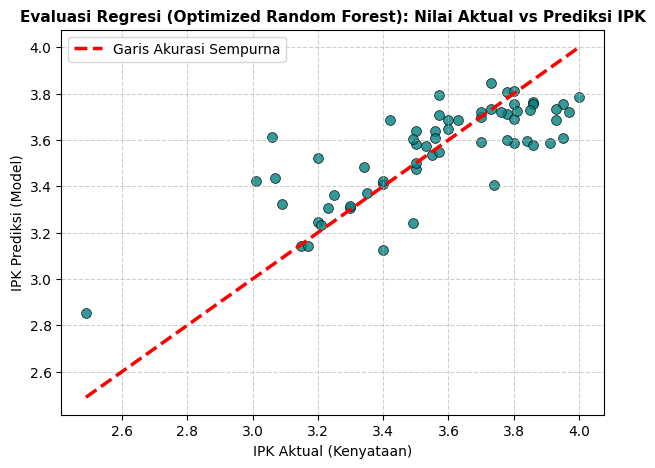

In [27]:
y_pred_final = model_terbaik_komplit.predict(X_test)

final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)

metrics_summary = pd.DataFrame({
    'Metrik Evaluasi': ['R2 Score', 'MAE (Mean Absolute Error)', 'MSE (Mean Squared Error)', 'RMSE (Root MSE)'],
    'Skor Performa Model Terbaik': [final_r2, final_mae, final_mse, final_rmse]
})
display(metrics_summary)

# Plot Evaluasi
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.8, color='teal', edgecolor='black', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Garis Akurasi Sempurna')
plt.title(f'Evaluasi Regresi ({nama_model_terbaik}): Nilai Aktual vs Prediksi IPK', fontsize=11, fontweight='bold')
plt.xlabel('IPK Aktual (Kenyataan)', fontsize=10)
plt.ylabel('IPK Prediksi (Model)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [28]:
import pickle

nama_file_regresi = f'BestModel_Regresi_{nama_model_terbaik.replace(" ", "")}_Kelompok3.pkl'

with open(nama_file_regresi, 'wb') as file:
    pickle.dump(model_terbaik_komplit, file)

print(f"Berhasil! Model regresi terbaik telah disimpan dengan nama: {nama_file_regresi}")


fitur_yang_dipakai = list(X.columns)
with open('FiturRegresi_Kelompok3.pkl', 'wb') as file:
    pickle.dump(fitur_yang_dipakai, file)

print(f"Daftar fitur juga disimpan ke FiturRegresi_Kelompok3.pkl")
print(f"\nJumlah fitur yang harus diisi user di Streamlit nanti: {len(fitur_yang_dipakai)}")

Berhasil! Model regresi terbaik telah disimpan dengan nama: BestModel_Regresi_OptimizedRandomForest_Kelompok3.pkl
Daftar fitur juga disimpan ke FiturRegresi_Kelompok3.pkl

Jumlah fitur yang harus diisi user di Streamlit nanti: 74
